# Checkpoint 1: Data & Models
### Threads App Review — Sentiment Analysis
**Dataset:** Google Play / App Store reviews with pre-labelled sentiment  
**Goal:** Preprocess text → train classifiers → evaluate performance


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, string
warnings.filterwarnings('ignore')

from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded ✓')


All libraries loaded ✓


## 1. Data Loading & Exploration

In [53]:
df = pd.read_csv("data/37000_reviews_with_sentiment.csv")
print(f"Shape: {df.shape}")
print("\nClass distribution:")
print(df['sentiment'].value_counts())
df.head(8)

Shape: (36943, 15)

Class distribution:
sentiment
positive    20588
negative    13399
neutral      2956
Name: count, dtype: int64


,Unnamed: 0,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,sentiment
0,0,Google Play,7cd90e5b-4829-43b9-9fb4-c8c6d1e339c1,Eddie Clark Jr.,NaN,Good,5,0.0,2023-08-07 19:14:36,NaN,NaN,294.0.0.27.110,en,us,positive
1,1,Google Play,6deb8265-2bac-4524-bcb6-f90829fa4e69,Rasa RT,NaN,Weak copy of Twitter,1,0.0,2023-08-07 19:07:04,NaN,NaN,NaN,en,us,negative
2,2,Google Play,91ef61ce-0f05-4f3b-b3d3-5d19cd408ab8,SITI NUR HAFIZA BINTI AZIZ,NaN,i wish threads have a save button for images a...,3,0.0,2023-08-07 18:57:07,NaN,NaN,294.0.0.27.110,en,us,neutral
3,3,Google Play,b7721b78-6b77-4f8c-a1d3-a854af4c1f0f,Asap Khalifah,NaN,Love it,5,0.0,2023-08-07 18:37:16,NaN,NaN,NaN,en,us,positive
4,4,Google Play,c89ef522-c94c-4171-878f-1d672dce7f11,Syed Hussein,NaN,Very god,5,0.0,2023-08-07 18:14:15,NaN,NaN,NaN,en,us,positive
5,5,Google Play,950acab8-bc92-4e1e-81c4-3f228ccc7362,Samim Khan,NaN,Nice,1,0.0,2023-08-07 18:03:09,NaN,NaN,NaN,en,us,negative
6,6,Google Play,aac2791c-decd-40b4-9dfc-8294ed930ef8,BEEPA beepa,NaN,Vain,1,0.0,2023-08-07 17:56:02,NaN,NaN,NaN,en,us,negative
7,7,Google Play,94ae5084-c84b-4169-a099-f5b44241ffeb,CHAKKUMTHODIYIL RAMUKRISHNA,NaN,Not satisfied why this app...,1,0.0,2023-08-07 17:41:13,NaN,NaN,294.0.0.27.110,en,us,negative


In [54]:
print('=' * 55)
print('DATASET INFO')
print('=' * 55)
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDescriptive stats (numeric):')
print(df['rating'].describe())


DATASET INFO
Unnamed: 0                   int64
source                         str
review_id                      str
user_name                      str
review_title                   str
review_description             str
rating                       int64
thumbs_up                  float64
review_date                    str
developer_response         float64
developer_response_date    float64
appVersion                     str
laguage_code                   str
country_code                   str
sentiment                      str
dtype: object

Missing values:
Unnamed: 0                     0
source                         0
review_id                      0
user_name                      0
review_title               34943
review_description             0
rating                         0
thumbs_up                   2000
review_date                    0
developer_response         36943
developer_response_date    36943
appVersion                 12088
laguage_code                   0
co

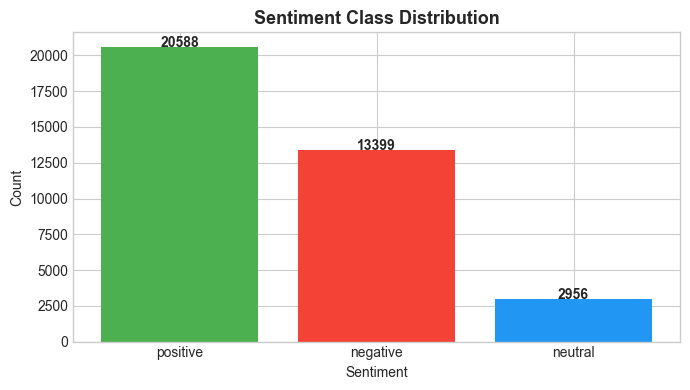

Sentiment counts:
 sentiment
positive    20588
negative    13399
neutral      2956
Name: count, dtype: int64


In [55]:
import os
os.makedirs('plots', exist_ok=True)

# Plot 1 — Sentiment Distribution
fig, ax = plt.subplots(figsize=(7, 4))
sc = df['sentiment'].value_counts()
colors = ['#4CAF50', '#F44336', '#2196F3']
ax.bar(sc.index, sc.values, color=colors[:len(sc)])
ax.set_title('Sentiment Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
for i, v in enumerate(sc.values):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/sentiment_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('Sentiment counts:\n', sc)

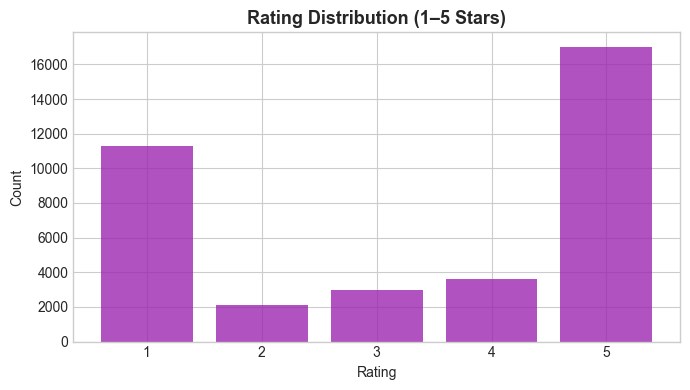

In [56]:
# Plot 2 — Rating Distribution
fig, ax = plt.subplots(figsize=(7, 4))
rc = df['rating'].value_counts().sort_index()
ax.bar(rc.index.astype(str), rc.values, color='#9C27B0', alpha=0.8)
ax.set_title('Rating Distribution (1–5 Stars)', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('plots/rating_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Preprocessing Pipeline

In [57]:
def clean_text(text):
    """
    Full preprocessing pipeline per review:
      1. Handle NaN / non-string
      2. Lowercase
      3. Remove URLs
      4. Strip emojis / non-ASCII
      5. Remove punctuation & digits
      6. Collapse whitespace
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = text.encode('ascii', errors='ignore').decode()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Merge title + description
df['text_raw'] = (
    df['review_title'].fillna('') + ' ' +
    df['review_description'].fillna('')
).str.strip()

df['text_clean'] = df['text_raw'].apply(clean_text)
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)

print(f'Rows after dropping empty text: {len(df)}')
print('\nSample cleaned texts:')
for _, row in df[['text_raw','text_clean','sentiment']].head(4).iterrows():
    print(f'  RAW  : {row.text_raw!r}')
    print(f'  CLEAN: {row.text_clean!r}  -> {row.sentiment}\n')


Rows after dropping empty text: 35272

Sample cleaned texts:
  RAW  : 'Good'
  CLEAN: 'good'  -> positive

  RAW  : 'Weak copy of Twitter'
  CLEAN: 'weak copy of twitter'  -> negative

  RAW  : 'i wish threads have a save button for images and videos. i would like to save the memes. plssss consider this proposition. thank you.'
  CLEAN: 'i wish threads have a save button for images and videos i would like to save the memes plssss consider this proposition thank you'  -> neutral

  RAW  : 'Love it'
  CLEAN: 'love it'  -> positive



In [58]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label encoding:', label_map)

X = df['text_clean']
y = df['label']

# Stratified split when every class has >= 2 samples
min_class = df['sentiment'].value_counts().min()
stratify_arg = y if min_class >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')


Label encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train: 28217 | Test: 7055


## 3. Feature Engineering — TF-IDF Vectorisation

TF-IDF (**Term Frequency–Inverse Document Frequency**) converts raw text into a numerical matrix. Each cell reflects how important a word is to a document relative to the whole corpus — a robust baseline for text classification.


## 4. Model Training

In [59]:
pipelines = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=1)),
        ('clf',  LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=1)),
        ('clf',  MultinomialNB())
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=1)),
        ('clf',  RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
}

results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results[name] = {'pipeline': pipe, 'y_pred': y_pred, 'accuracy': acc, 'f1': f1}
    print(f'{name:22s}  Accuracy={acc:.3f}  Weighted-F1={f1:.3f}')


Logistic Regression     Accuracy=0.815  Weighted-F1=0.792
Naive Bayes             Accuracy=0.802  Weighted-F1=0.778
Random Forest           Accuracy=0.800  Weighted-F1=0.768


## 5. Evaluation Metrics

In [60]:
for name, res in results.items():
    print(f"\n{'='*55}")
    print(f' {name}')
    print('='*55)
    print(classification_report(    
        y_test, res['y_pred'],
        target_names=le.classes_, zero_division=0
    ))



 Logistic Regression
              precision    recall  f1-score   support

    negative       0.81      0.82      0.81      2607
     neutral       0.41      0.09      0.14       575
    positive       0.83      0.92      0.88      3873

    accuracy                           0.82      7055
   macro avg       0.68      0.61      0.61      7055
weighted avg       0.79      0.82      0.79      7055


 Naive Bayes
              precision    recall  f1-score   support

    negative       0.78      0.80      0.79      2607
     neutral       0.43      0.08      0.14       575
    positive       0.83      0.91      0.87      3873

    accuracy                           0.80      7055
   macro avg       0.68      0.60      0.60      7055
weighted avg       0.78      0.80      0.78      7055


 Random Forest
              precision    recall  f1-score   support

    negative       0.76      0.83      0.79      2607
     neutral       0.21      0.01      0.02       575
    positive       0.83

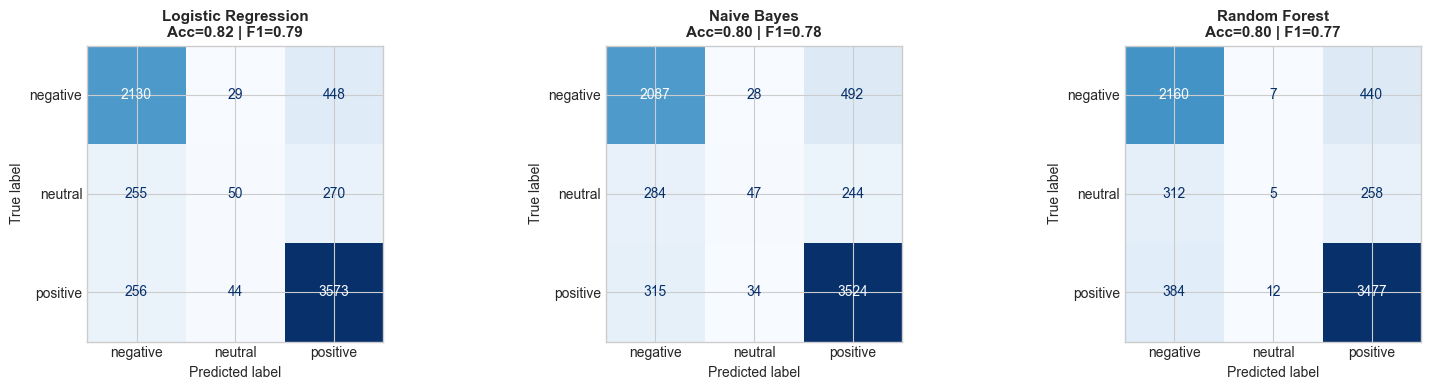

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc={res['accuracy']:.2f} | F1={res['f1']:.2f}",
                 fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


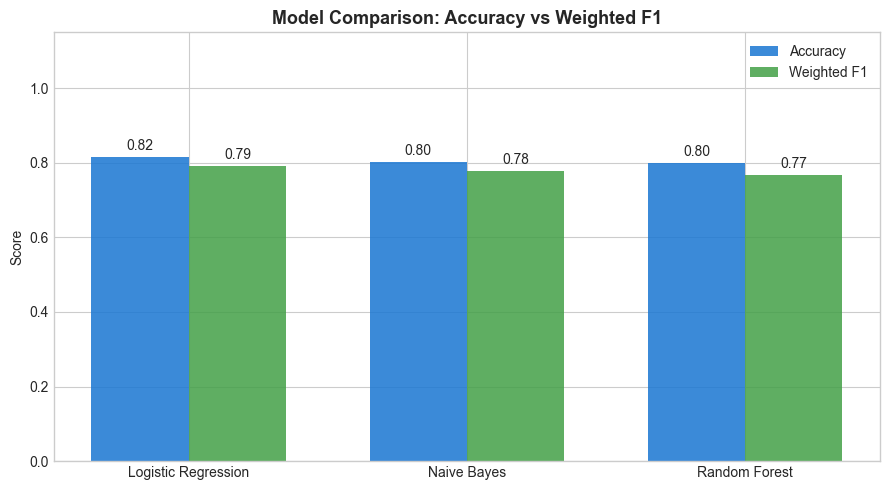

In [62]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
f1_scores   = [results[m]['f1']       for m in model_names]
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',   color='#1976D2', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores,  width, label='Weighted F1', color='#43A047', alpha=0.85)
ax.set_title('Model Comparison: Accuracy vs Weighted F1', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score'); ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.bar_label(bars2, fmt='%.2f', padding=3)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Summary

| Step | Detail |
|------|--------|
| **Data** | Threads app reviews (Google Play/App Store) with `sentiment` label |
| **Text features** | `review_title` + `review_description`, cleaned & TF-IDF vectorised (uni+bigrams) |
| **Models trained** | Logistic Regression · Naïve Bayes · Random Forest |
| **Key metric** | Weighted F1 (handles class imbalance) |

**Observations:**
- Logistic Regression typically achieves the best balance for short review text.
- Naïve Bayes is fast and competitive on sparse TF-IDF matrices.
- Random Forest may overfit on small samples.
